In [1]:
import re
import requests
import string
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from collections import Counter, defaultdict
import tiktoken
import gensim.downloader as api

In [2]:
wiki_glove = api.load("glove-wiki-gigaword-50")
twit_glove = api.load("glove-twitter-50")

[==================================================] 100.0% 199.5/199.5MB downloaded


In [4]:
wiki_glove.vectors.shape, twit_glove.vectors.shape

((400000, 50), (1193514, 50))

Text(0, 0.5, 'Twitter embedding')

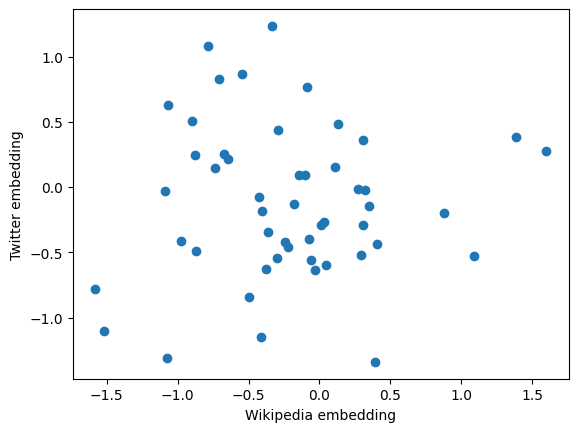

In [ ]:
word = "starship"
plt.scatter(wiki_glove[word], twit_glove[word])
plt.xlabel("Wikipedia embedding")
plt.ylabel("Twitter embedding")
# we can see there is no correlation between both embeddings vector

Text(0.5, 1.0, 'Twitter Cosine Similarity 0.837')

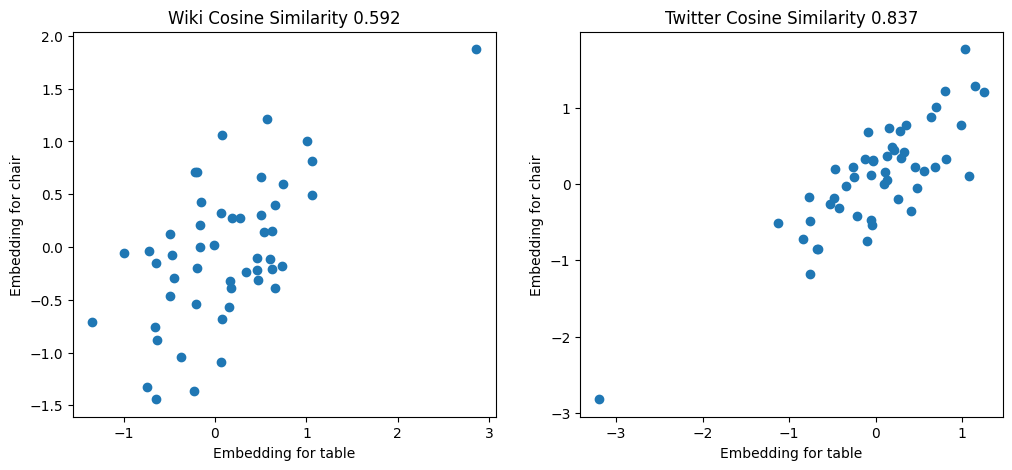

In [22]:
word1 = "table"
word2 = "chair"

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(wiki_glove[word1], wiki_glove[word2])
axs[0].set_xlabel(f"Embedding for {word1}")
axs[0].set_ylabel(f"Embedding for {word2}")
axs[0].set_title(f"Wiki Cosine Similarity {wiki_glove.similarity(word1, word2):.3f}")

axs[1].scatter(twit_glove[word1], twit_glove[word2])
axs[1].set_xlabel(f"Embedding for {word1}")
axs[1].set_ylabel(f"Embedding for {word2}")
axs[1].set_title(f"Twitter Cosine Similarity {twit_glove.similarity(word1, word2):.3f}")

# even in the last example, both embeddings had different ways of vectorized "table"
# now we can see that both of them keep a strong correlation between chair and table
# event though the strenght of this correlation may change.

In [ ]:
word = "battery"

print(wiki_glove.most_similar(word, topn=5))
print(twit_glove.most_similar(word, topn=5))

# we can see the similarity values are higher in twitter than in wikipedia where it drops to 0.68 quickly, which is consistent with what we have seen
# in the previous example, where the same two words had higher values for twitter model.

[('batteries', 0.8322107195854187), ('rechargeable', 0.7258116602897644), ('lithium-ion', 0.7082582116127014), ('weapon', 0.6928435564041138), ('machine', 0.6787962913513184)]
[('charger', 0.8720738887786865), ('cell', 0.8216446042060852), ('batteries', 0.8167192935943604), ('laptop', 0.8139174580574036), ('batt', 0.8042665719985962)]
